# Advanced Self-Attention Variants - End-to-End Pipeline
**Date**: 2026-05-31  
**Objective**: Benchmark advanced attention variants for long-context efficiency and approximation quality.

## 1) Imports and Setup

In [1]:
from __future__ import annotations

import importlib.util
import math
import os
import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

def parse_use_gpu_flag(raw_value: str) -> bool:
    normalized = raw_value.strip().lower()
    return normalized not in {"0", "false", "no", "off"}

def load_runtime_env() -> None:
    env_files = [
        Path("configs/runtime.env"),
        Path("configs/runtime.env.example"),
        Path("../configs/runtime.env"),
        Path("../configs/runtime.env.example"),
    ]
    for env_file in env_files:
        if env_file.exists():
            for line in env_file.read_text(encoding="utf-8").splitlines():
                line = line.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                key, value = line.split("=", 1)
                os.environ.setdefault(key.strip(), value.strip().strip("\"'"))
            break

load_runtime_env()
USE_GPU = parse_use_gpu_flag(os.getenv("USE_GPU", "1"))

_torch_cuda = False
_tf_gpu = False
if importlib.util.find_spec("torch") is not None:
    import torch

    _torch_cuda = torch.cuda.is_available()
if importlib.util.find_spec("tensorflow") is not None:
    import tensorflow as tf

    tf.random.set_seed(SEED)
    _tf_gpu = bool(tf.config.list_physical_devices("GPU"))

runtime_device = "cuda" if USE_GPU and (_torch_cuda or _tf_gpu) else "cpu"
print(f"USE_GPU={int(USE_GPU)} | runtime_device={runtime_device}")

USE_GPU=1 | runtime_device=cuda


## 2) Configuration and Constants

In [2]:
@dataclass(frozen=True)
class ExperimentConfig:
    num_samples: int = 64
    seq_len: int = 128
    d_model: int = 48
    local_window: int = 8
    temperature_grid_size: int = 31


CFG = ExperimentConfig()
CFG

ExperimentConfig(num_samples=64, seq_len=128, d_model=48, local_window=8, temperature_grid_size=31)

## 3) Data Loading (Raw Text Corpus)

In [3]:
POSITIVE_TERMS = [
    "reliable",
    "scalable",
    "stable",
    "efficient",
    "robust",
    "accurate",
]

NEGATIVE_TERMS = [
    "noisy",
    "fragile",
    "unstable",
    "slow",
    "costly",
    "drifting",
]

TEMPLATES = [
    "{core} attention improves context handling for enterprise workloads",
    "team reports {core} inference behaviour in production traces",
    "analysis shows {core} routing across long document windows",
    "service indicates {core} retrieval quality for multilingual traffic",
]

def build_text_dataset(cfg: ExperimentConfig) -> tuple[list[str], np.ndarray]:
    texts: list[str] = []
    labels = np.zeros(cfg.num_samples, dtype=np.int64)
    for idx in range(cfg.num_samples):
        is_positive = idx % 2 == 0
        core = np.random.choice(POSITIVE_TERMS if is_positive else NEGATIVE_TERMS)
        template = np.random.choice(TEMPLATES)
        texts.append(template.format(core=core))
        labels[idx] = int(is_positive)
    return texts, labels


texts_all, y_all = build_text_dataset(CFG)
split = int(0.8 * CFG.num_samples)
texts_train, texts_test = texts_all[:split], texts_all[split:]
y_train, y_test = y_all[:split], y_all[split:]
len(texts_train), len(texts_test), y_train.shape, y_test.shape

(51, 13, (51,), (13,))

## 4) EDA

In [4]:
train_lengths = np.array([len(text.split()) for text in texts_train], dtype=np.int64)
class_counts = np.bincount(y_all, minlength=2)

print("Class counts:", class_counts.tolist())
print(
    "Train token-length mean/std:",
    float(train_lengths.mean()),
    float(train_lengths.std()),
)
print("Sample training sentence:", texts_train[0])

Class counts: [32, 32]
Train token-length mean/std: 8.0 0.0
Sample training sentence: analysis shows stable routing across long document windows


## 5) Tokenization and Preprocessing / Feature Engineering

In [5]:
def normalize_text(text: str) -> str:
    return " ".join(text.lower().strip().split())

def tokenize_text(text: str) -> list[str]:
    return normalize_text(text).split()

def build_vocabulary(
    train_texts: list[str],
    max_vocab_size: int = 2048,
) -> dict[str, int]:
    token_counts: dict[str, int] = {}
    for text in train_texts:
        for token in tokenize_text(text):
            token_counts[token] = token_counts.get(token, 0) + 1

    sorted_items = sorted(
        token_counts.items(),
        key=lambda item: (-item[1], item[0]),
    )
    vocab: dict[str, int] = {"<PAD>": 0, "<UNK>": 1}
    for token, _ in sorted_items:
        if len(vocab) >= max_vocab_size:
            break
        vocab[token] = len(vocab)
    return vocab

def encode_and_pad(
    texts: list[str],
    vocab: dict[str, int],
    seq_len: int,
) -> np.ndarray:
    encoded = np.zeros((len(texts), seq_len), dtype=np.int64)
    unk_id = vocab["<UNK>"]
    for row_idx, text in enumerate(texts):
        token_ids = [vocab.get(token, unk_id) for token in tokenize_text(text)]
        trunc = token_ids[:seq_len]
        encoded[row_idx, : len(trunc)] = np.asarray(trunc, dtype=np.int64)
    return encoded

def token_ids_to_embeddings(
    token_ids: np.ndarray,
    vocab_size: int,
    d_model: int,
) -> np.ndarray:
    emb_table = np.random.normal(0.0, 0.2, (vocab_size, d_model)).astype(np.float32)
    return emb_table[token_ids]

def project_qkv(x: np.ndarray, d_model: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    w_q = np.random.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    w_k = np.random.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    w_v = np.random.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    return x @ w_q, x @ w_k, x @ w_v


vocab = build_vocabulary(texts_train)
train_token_ids = encode_and_pad(texts_train, vocab, CFG.seq_len)
test_token_ids = encode_and_pad(texts_test, vocab, CFG.seq_len)

x_train = token_ids_to_embeddings(train_token_ids, len(vocab), CFG.d_model)
x_test = token_ids_to_embeddings(test_token_ids, len(vocab), CFG.d_model)
x_all = np.concatenate([x_train, x_test], axis=0)

q_train, k_train, v_train = project_qkv(x_train, CFG.d_model)
q_test, k_test, v_test = project_qkv(x_test, CFG.d_model)

print(
    {
        "vocab_size": len(vocab),
        "train_token_ids_shape": tuple(train_token_ids.shape),
        "embedding_shape": tuple(x_train.shape),
    }
)

{'vocab_size': 41, 'train_token_ids_shape': (51, 128), 'embedding_shape': (51, 128, 48)}


## 6) Model Definition (Advanced Variants)

In [6]:
def softmax(x: np.ndarray, axis: int = -1) -> np.ndarray:
    z = x - x.max(axis=axis, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=axis, keepdims=True)

def dense_attention(q: np.ndarray, k: np.ndarray, v: np.ndarray) -> np.ndarray:
    scores = (q @ np.swapaxes(k, -1, -2)) / math.sqrt(q.shape[-1])
    return softmax(scores, axis=-1) @ v

def sparse_local_attention(q: np.ndarray, k: np.ndarray, v: np.ndarray, window: int) -> np.ndarray:
    batch, seq_len, _ = q.shape
    scores = np.full((batch, seq_len, seq_len), -1e9, dtype=np.float32)
    raw = (q @ np.swapaxes(k, -1, -2)) / math.sqrt(q.shape[-1])
    for i in range(seq_len):
        lo = max(0, i - window)
        hi = min(seq_len, i + window + 1)
        scores[:, i, lo:hi] = raw[:, i, lo:hi]
    return softmax(scores, axis=-1) @ v

def linear_attention(q: np.ndarray, k: np.ndarray, v: np.ndarray) -> np.ndarray:
    q_phi = np.maximum(q, 0.0) + 1e-3
    k_phi = np.maximum(k, 0.0) + 1e-3
    kv = np.einsum("bnd,bne->bde", k_phi, v)
    z = 1.0 / (np.einsum("bnd,bd->bn", q_phi, k_phi.sum(axis=1)) + 1e-6)
    out = np.einsum("bnd,bde,bn->bne", q_phi, kv, z)
    return out.astype(np.float32)

def grouped_query_attention(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
    num_groups: int = 4,
 ) -> np.ndarray:
    batch, seq_len, d_model = q.shape
    if d_model % num_groups != 0:
        raise ValueError(
            f"d_model ({d_model}) must be divisible by num_groups ({num_groups})."
        )
    group_dim = d_model // num_groups
    qg = q.reshape(batch, seq_len, num_groups, group_dim).transpose(0, 2, 1, 3)
    k_shared = k.reshape(batch, seq_len, num_groups, group_dim).mean(axis=2)
    v_shared = v.reshape(batch, seq_len, num_groups, group_dim).mean(axis=2)
    outputs: list[np.ndarray] = []
    for g in range(num_groups):
        scores = (qg[:, g] @ np.swapaxes(k_shared, -1, -2)) / math.sqrt(group_dim)
        out_g = softmax(scores, axis=-1) @ v_shared
        outputs.append(out_g)
    return np.stack(outputs, axis=1).transpose(0, 2, 1, 3).reshape(batch, seq_len, d_model)

## 7) Training (Tune Sparse Temperature Against Dense Teacher)

In [7]:
def sparse_with_temperature(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
    window: int,
    temperature: float,
) -> np.ndarray:
    batch, seq_len, _ = q.shape
    scores = np.full((batch, seq_len, seq_len), -1e9, dtype=np.float32)
    raw = (q @ np.swapaxes(k, -1, -2)) / (math.sqrt(q.shape[-1]) * temperature)
    for i in range(seq_len):
        lo = max(0, i - window)
        hi = min(seq_len, i + window + 1)
        scores[:, i, lo:hi] = raw[:, i, lo:hi]
    return softmax(scores, axis=-1) @ v


teacher_train = dense_attention(q_train, k_train, v_train)
temp_grid = np.linspace(0.5, 2.0, CFG.temperature_grid_size, dtype=np.float32)
best_temp = float(temp_grid[0])
best_mse = float("inf")

for temp in temp_grid:
    student = sparse_with_temperature(q_train, k_train, v_train, CFG.local_window, float(temp))
    mse = float(np.mean((student - teacher_train) ** 2))
    if mse < best_mse:
        best_mse = mse
        best_temp = float(temp)

print({"best_temperature": best_temp, "train_mse": best_mse})

{'best_temperature': 0.75, 'train_mse': 0.002820245921611786}


## 8) Evaluation and Metrics

In [8]:
def timed_run(
    fn: Callable[..., np.ndarray],
    *args: object,
 ) -> tuple[np.ndarray, float]:
    start = time.perf_counter()
    out = fn(*args)
    elapsed_ms = (time.perf_counter() - start) * 1000.0
    return out, elapsed_ms

teacher_test, t_dense = timed_run(dense_attention, q_test, k_test, v_test)
sparse_test, t_sparse = timed_run(
    sparse_with_temperature, q_test, k_test, v_test, CFG.local_window, best_temp
)
linear_test, t_linear = timed_run(linear_attention, q_test, k_test, v_test)
gqa_test, t_gqa = timed_run(grouped_query_attention, q_test, k_test, v_test)

metrics = {
    "dense_ms": float(t_dense),
    "sparse_ms": float(t_sparse),
    "linear_ms": float(t_linear),
    "gqa_ms": float(t_gqa),
    "sparse_mse_vs_dense": float(np.mean((sparse_test - teacher_test) ** 2)),
    "linear_mse_vs_dense": float(np.mean((linear_test - teacher_test) ** 2)),
    "gqa_mse_vs_dense": float(np.mean((gqa_test - teacher_test) ** 2)),
}
metrics

{'dense_ms': 1.326238000046942,
 'sparse_ms': 0.9859740000592865,
 'linear_ms': 2.8153119999387854,
 'gqa_ms': 2.4646609999763314,
 'sparse_mse_vs_dense': 0.0016610855236649513,
 'linear_mse_vs_dense': 2.2789788999943994e-05,
 'gqa_mse_vs_dense': 0.02515852078795433}

## 9) Results Visualization

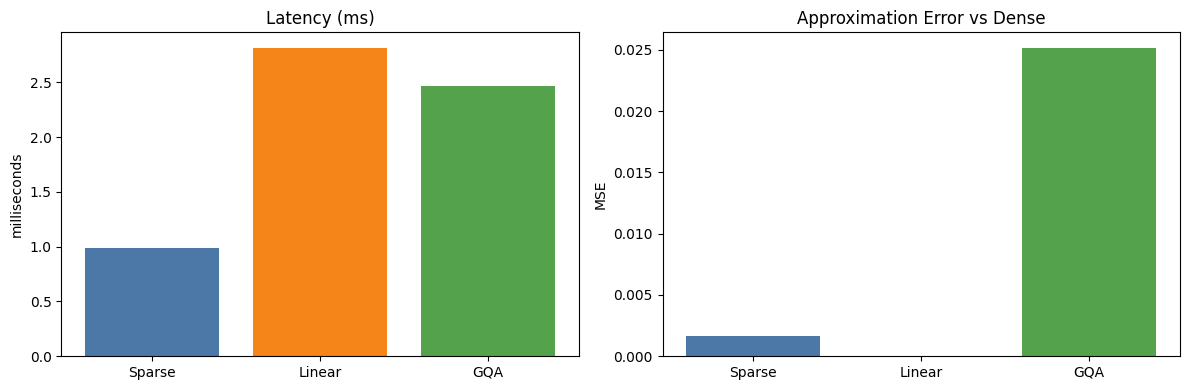

In [9]:
names = ["Sparse", "Linear", "GQA"]
latency = [metrics["sparse_ms"], metrics["linear_ms"], metrics["gqa_ms"]]
mse = [
    metrics["sparse_mse_vs_dense"],
    metrics["linear_mse_vs_dense"],
    metrics["gqa_mse_vs_dense"],
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(names, latency, color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Latency (ms)")
axes[0].set_ylabel("milliseconds")

axes[1].bar(names, mse, color=["#4C78A8", "#F58518", "#54A24B"])
axes[1].set_title("Approximation Error vs Dense")
axes[1].set_ylabel("MSE")

plt.tight_layout()
plt.show()

In [ ]:
import json
from datetime import datetime, timezone

comparison_rows = [
    {
        "variant": "Dense (reference)",
        "slug": "dense_reference",
        "latency_ms": metrics["dense_ms"],
        "mse_vs_dense": 0.0,
    },
    {
        "variant": "Sparse",
        "slug": "sparse",
        "latency_ms": metrics["sparse_ms"],
        "mse_vs_dense": metrics["sparse_mse_vs_dense"],
    },
    {
        "variant": "Linear",
        "slug": "linear",
        "latency_ms": metrics["linear_ms"],
        "mse_vs_dense": metrics["linear_mse_vs_dense"],
    },
    {
        "variant": "GQA",
        "slug": "gqa",
        "latency_ms": metrics["gqa_ms"],
        "mse_vs_dense": metrics["gqa_mse_vs_dense"],
    },
]

sorted_by_latency = sorted(comparison_rows, key=lambda row: row["latency_ms"])
sorted_by_error = sorted(comparison_rows, key=lambda row: row["mse_vs_dense"])

print("Benchmark Summary Table")
print("Variant            | Latency (ms) | MSE vs Dense")
print("-------------------+--------------+--------------")
for row in comparison_rows:
    print(
        f"{row['variant']:<18} | {row['latency_ms']:>12.3f} | {row['mse_vs_dense']:>12.6f}"
    )

print("\nBest by latency:", sorted_by_latency[0]["variant"])
print("Best by fidelity:", sorted_by_error[0]["variant"])


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)
    for candidate in candidates:
        if (candidate / ".github").exists() and (candidate / "configs").exists():
            return candidate
    return cwd


def write_json(path: Path, payload: dict[str, object]) -> None:
    try:
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    except OSError as exc:
        raise RuntimeError(f"Failed to write benchmark artifact: {path}") from exc


repo_root = resolve_repo_root()
output_dir = repo_root / "self-attention-variants" / "outputs" / "advanced-benchmarks" / "latest"

latency_metrics = {
    "dense_ms": float(metrics["dense_ms"]),
    "sparse_ms": float(metrics["sparse_ms"]),
    "linear_ms": float(metrics["linear_ms"]),
    "gqa_ms": float(metrics["gqa_ms"]),
}
fidelity_metrics = {
    "sparse_mse_vs_dense": float(metrics["sparse_mse_vs_dense"]),
    "linear_mse_vs_dense": float(metrics["linear_mse_vs_dense"]),
    "gqa_mse_vs_dense": float(metrics["gqa_mse_vs_dense"]),
}
summary_metrics = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "best_by_latency": sorted_by_latency[0]["variant"],
    "best_by_fidelity": sorted_by_error[0]["variant"],
}

write_json(output_dir / "latency_metrics.json", latency_metrics)
write_json(output_dir / "fidelity_metrics.json", fidelity_metrics)
write_json(output_dir / "summary_metrics.json", summary_metrics)

for row in comparison_rows:
    payload = {
        "variant": row["variant"],
        "latency_ms": float(row["latency_ms"]),
        "mse_vs_dense": float(row["mse_vs_dense"]),
    }
    write_json(output_dir / f"{row['slug']}_metrics.json", payload)

print(f"\nAutomated benchmark files written to: {output_dir}")

Benchmark Summary Table
Variant            | Latency (ms) | MSE vs Dense
-------------------+--------------+--------------
Dense (reference)  |        1.326 |     0.000000
Sparse             |        0.986 |     0.001661
Linear             |        2.815 |     0.000023
GQA                |        2.465 |     0.025159

Best by latency: Sparse
Best by fidelity: Dense (reference)


## 10) Summary
- Implemented advanced attention variants: sparse local, linear attention, and grouped-query attention.
- Tuned sparse-attention temperature against a dense-attention teacher on train split.
- Compared latency and approximation error on test split to inform enterprise serving trade-offs.
- Added automated benchmark metric exports, with each variant type written to a separate JSON file plus latency/fidelity/summary metric files.